# Exploratory data analysis

A quick dive into the two datasets used in the comparison verifying the following:
1. the cross dataset labels have the correct mapping
2. correct dataset sizes, resolution and class balances
3. the domain shift and possibly identify difficulties

In this project one sample refers to one UAV RGB image and its pixel level segmentation mask

### Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from src.datasets import(
COMMON_CLASS_NAMES, SemanticDroneDataset, UAVidDataset
)

In [2]:
# simple colour palette for vis!
COMMON_PALETTE = {
    0: (180, 30, 30),
    1: (128, 64, 128),
    2:(40, 150, 40),
    3:(220, 180, 20),
    4: (255, 22, 96),
    5: (80,80,80)
}

### loading the datasets

In [3]:
# paths for reproducibility

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SEMANTIC_DRONE_ROOT = PROJECT_ROOT / "data" / "semantic_drone"
UAVID_ROOT = PROJECT_ROOT / "data" / "uavid"

In [4]:
semantic_drone = SemanticDroneDataset(SEMANTIC_DRONE_ROOT)
uavid_train = UAVidDataset(UAVID_ROOT, split="train")
uavid_val = UAVidDataset(UAVID_ROOT, split="val")
# test is not necessary as it does not carry any masks!

In [5]:
print("Datasets lengths:\n"
      f"semantic drone = {len(semantic_drone)}\n"
      f"uavid train = {len(uavid_train)}\n"
      f"uavid val = {len(uavid_val)}")

Datasets lengths:
semantic drone = 400
uavid train = 600
uavid val = 70


In [6]:
semantic_img, semantic_mask = semantic_drone[0]
uavid_img, uavid_mask = uavid_train[0]

print(f"Semantic img shape (C, H, W): {semantic_img.shape}, semantic mask shape: {semantic_mask.shape}"
      f"\nuavid img shape{uavid_img.shape}, uavid mask shape{uavid_mask.shape}")


Semantic img shape (C, H, W): torch.Size([3, 4000, 6000]), semantic mask shape: torch.Size([4000, 6000])
uavid img shapetorch.Size([3, 2160, 3840]), uavid mask shapetorch.Size([2160, 3840])


In [7]:
print(f"semantic img type {semantic_img.dtype}, semantic mask type {semantic_mask.dtype}")
print(f"uavid img type {uavid_img.dtype}, uavid mask type {uavid_mask.dtype}")

semantic img type torch.float32, semantic mask type torch.int64
uavid img type torch.float32, uavid mask type torch.int64


In [8]:
print(semantic_img.min(), semantic_img.max())
print(uavid_img.min(), uavid_img.max())

tensor(0.) tensor(1.)
tensor(0.) tensor(1.)


In [9]:
# this is managed later anyways!
print(torch.unique(semantic_mask))
print(torch.unique(uavid_mask))

tensor([0, 1, 2, 4, 5])
tensor([0, 1, 2, 3, 4, 5])


In [10]:
def colorize_common_mask(mask: torch.Tensor)-> np.ndarray:
    """ converts HxW common class mask to HxWx3 RGB array"""
    # for passing into matplot later
    integer_mask = mask.detach().cpu().numpy()

    height, width = integer_mask.shape
    rgb_mask = np.zeros((height, width,3), np.uint8)

    for class_id, colour in COMMON_PALETTE.items():
        rgb_mask[integer_mask == class_id] = colour

    return rgb_mask

def class_pixel_counts( mask: torch.Tensor, num_classes: int = len(COMMON_CLASS_NAMES)) -> torch.Tensor:

    # for easier iteration later on the CPU!
    flat_mask = mask.detach().to(device="cpu", dtype=torch.int64).flatten()

    if flat_mask.numel() == 0:
        return torch.zeros(num_classes, dtype=torch.int64)

    return torch.bincount(flat_mask, minlength=num_classes)

In [11]:
colourized_mask = colorize_common_mask(semantic_mask)
counts = class_pixel_counts(semantic_mask)

print("colourized mask shape", colourized_mask.shape)
print("counts", counts)

print("total counted", counts.sum().item())
print("total pixels", semantic_mask.numel())


assert colourized_mask.shape == (*semantic_mask.shape, 3)
assert colourized_mask.dtype == np.uint8
assert counts.shape == (len(COMMON_CLASS_NAMES),)
assert counts.sum().item() == semantic_mask.numel()
assert semantic_mask.min().item() >= 0
assert semantic_mask.max().item() < len(COMMON_CLASS_NAMES)


colourized mask shape (4000, 6000, 3)
counts tensor([  287613, 20883680,   800941,        0,   524123,  1503643])
total counted 24000000
total pixels 24000000


In [12]:
for class_name, count in zip(COMMON_CLASS_NAMES, counts):
    percentage = 100 * count.item() / semantic_mask.numel()
    print(f"{class_name:>10}: {count.item():>10,} pixels ({percentage:6.2f}%)")

  Building:    287,613 pixels (  1.20%)
      Road: 20,883,680 pixels ( 87.02%)
Vegetation:    800,941 pixels (  3.34%)
   Vehicle:          0 pixels (  0.00%)
     Human:    524,123 pixels (  2.18%)
     Other:  1,503,643 pixels (  6.27%)


### Visual inspection of label mapping

In [13]:
sample_index = 0
image, common_mask = semantic_drone[sample_index]
image_path, original_mask_path = semantic_drone.samples[sample_index]

In [14]:
with Image.open(original_mask_path) as mask_image:
    original_mask = np.asarray(mask_image.convert("RGB"))

type(original_mask)

numpy.ndarray

In [15]:
display_stride = 4

display_img = (
    image[:,::display_stride,::display_stride].permute(1,2,0).cpu().numpy()
) # permut is bc of the super annyoning non standard order of the shape

display_original_mask = original_mask[
    ::display_stride, ::display_stride
]

display_common_mask = colorize_common_mask(common_mask[::display_stride, ::display_stride]) # downsampling

print("Displayed image:", display_img.shape)
print("Displayed original mask:", display_original_mask.shape)
print("Displayed common mask:", display_common_mask.shape)

assert display_img.shape == display_original_mask.shape
assert display_img.shape == display_common_mask.shape

Displayed image: (1000, 1500, 3)
Displayed original mask: (1000, 1500, 3)
Displayed common mask: (1000, 1500, 3)


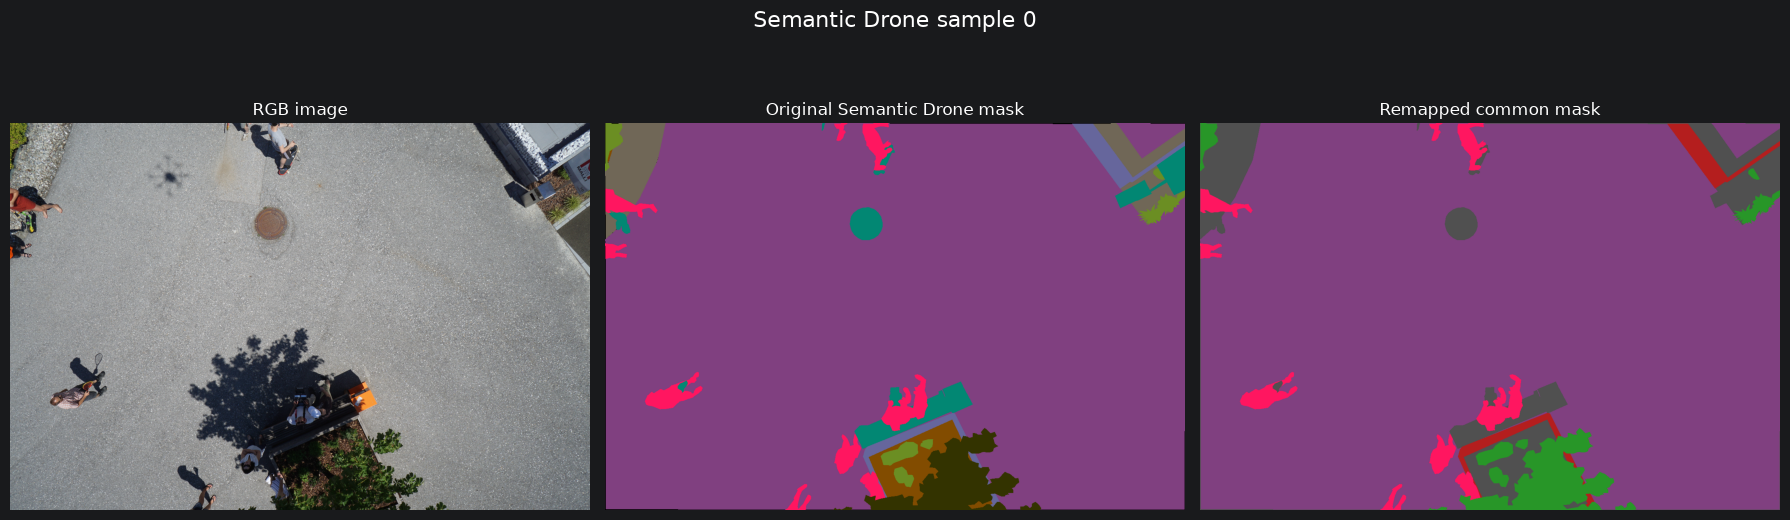

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(display_img)
axes[0].set_title("RGB image")

axes[1].imshow(display_original_mask)
axes[1].set_title("Original Semantic Drone mask")

axes[2].imshow(display_common_mask)
axes[2].set_title("Remapped common mask")

for axis in axes:
    axis.axis("off")

fig.suptitle(f"Semantic Drone sample {sample_index}", fontsize=16)
plt.tight_layout()
plt.show()

## observations

THe remapping seemed to have worked and by breif visual inspection of this sample, it is semantically cohereant to eachother. Especially humans and their own class may be important later and it's going to be very interesting to seee the effect of humans on the drone landing behaviour!